In [1]:

import matplotlib.pyplot as plt
import time
import torch
import numpy as np
from sympy.codegen.rewriting import Optimization
from tqdm import tqdm
from tqdm.notebook import tqdm
import pandas as pd
import torch
import os
from datetime import datetime
import sys
import json
from matplotlib.ticker import LogLocator, LogFormatter
from tqdm import trange
from functools import partial

In [2]:
!pip install flow_matching -q
!pip install POT -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.6 MB/s eta 0:00:00


In [3]:
import os
import sys
from huggingface_hub import login
from google.colab import userdata
import wandb

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "adding-simu-compare"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"✅ Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f"/content/{repo_name}"
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    print(f"\n✅ Repo ready. Branch: {branch}")
    print(f"📁 Python path: {repo_path}")

repo_path = f"/content/{repo_name}/simulations"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.6 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5088, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 5088 (delta 150), reused 152 (delta 84), pack-reused 4857 (from 3)
Receiving objects: 100% (5088/5088), 1.04 GiB | 14.02 MiB/s, done.
Resolving deltas: 100% (1132/1132), done.
Branch 'adding-simu-compare' set up to track remote branch 'adding-simu-compare' from 'origin'.
Switched to a new branch 'adding-simu-compare'

✅ Repo ready. Branch: adding-simu-compare
📁 Python path: /content/conditional-matching-paper


In [4]:
import importlib
import Diffusion


import LossFunctions
import ConsistencyModels
import  FlowMatching
from ConsistencyModels import ConsistencyModel,ConsistencyModeliCT
import dist_utils
import Optimization
import evalModels

importlib.reload(Diffusion)
importlib.reload(LossFunctions)

importlib.reload(ConsistencyModels)
importlib.reload(FlowMatching)
importlib.reload(dist_utils)
importlib.reload(Optimization)



<module 'Optimization' from '/content/conditional-matching-paper/simulations/Optimization.py'>

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:

def summary_row(name, l2_gmm, l2_x, times):
    return {
        "Method":               name,
        "L2 GMM mean":          f"{np.mean(l2_gmm):.4f}",
        "L2 GMM std":           f"{np.std(l2_gmm):.4f}",
        "L2 to x* mean":        f"{np.mean(l2_x):.4f}",
        "L2 to x* std":         f"{np.std(l2_x):.4f}",
        "Time mean (s)":        f"{np.mean(times):.2f}",
        "Time std (s)":         f"{np.std(times):.2f}",
    }


def top10_stats(name, final_loss, l2_gmm, l2_x, times):
    losses = [fl.item() if hasattr(fl, 'item') else fl for fl in final_loss]
    k = min(10, len(losses))
    top10_idx = np.argsort(losses)[:k]

    top10_loss = [losses[i]    for i in top10_idx]
    top10_gmm  = [l2_gmm[i]   for i in top10_idx]
    top10_x    = [l2_x[i]     for i in top10_idx]
    top10_time = [times[i]     for i in top10_idx]

    return {
        "Method":            name,
        "Loss mean":         f"{np.mean(top10_loss):.4f}",
        "Loss std":          f"{np.std(top10_loss):.4f}",
        "L2 GMM mean":       f"{np.mean(top10_gmm):.4f}",
        "L2 GMM std":        f"{np.std(top10_gmm):.4f}",
        "L2 to x* mean":     f"{np.mean(top10_x):.4f}",
        "L2 to x* std":      f"{np.std(top10_x):.4f}",
        "Time mean (s)":     f"{np.mean(top10_time):.2f}",
        "Time std (s)":      f"{np.std(top10_time):.2f}",
        "Top-k selected":    k,
    }


# 2D cond on 1D

In [7]:
mu_list = [torch.tensor([-5,5],dtype=torch.float64),
           torch.tensor([-5,-5],dtype=torch.float64),
           torch.tensor([5, 3],dtype=torch.float64),
           torch.tensor([5,-1],dtype=torch.float64),
           torch.tensor([0, -3],dtype=torch.float64),
           torch.tensor([-2,4 ],dtype=torch.float64),
           torch.tensor([-2,-3 ],dtype=torch.float64),
           torch.tensor([ 1,2],dtype=torch.float64),
           torch.tensor([-8,1],dtype=torch.float64),
           torch.tensor([7,5],dtype=torch.float64),
           torch.tensor([0,-5],dtype=torch.float64)
           ]

Sigma_list = [
    torch.tensor([[0.5000, 0.1950],
                  [0.1950, 0.2000]], dtype=torch.float64)
              ] * len(mu_list)

# Mixture weights
alpha =torch.tensor( [1 / len(mu_list)] * len(mu_list),dtype=torch.float64)

mu_list = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha = alpha.float()

## Target
x_star=torch.tensor([-5])
mu_temp, Sigma_temp =dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
temp_alpha = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
mog_means, mog_variances, weights= dist_utils.filter_and_normalize(mu_temp, Sigma_temp, temp_alpha, threshold=0.01)


/content/conditional-matching-paper/simulations/dist_utils.py:466: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff


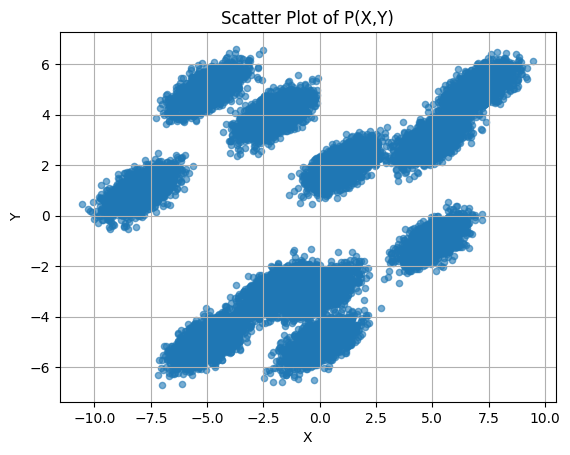

In [8]:
X = dist_utils.generate_mog_samples(25_000, mu_list, Sigma_list, alpha).float().to(device)
xh_cpu = X.detach().cpu().numpy()

# Scatter plot of first column vs. second column
plt.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.6, s=20)
plt.title("Scatter Plot of P(X,Y)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## Parameters for tests

In [9]:
## NN
nblocks=3
nunits=128
nepochs=20_000
batch_size=512

nepochs_CM=7_500
batch_size_CM=1024

## Diffusion
diffusion_steps=100

## Optimization
n_attemp_optim=25
nsamples_in_optim_for_mmd=250


# For models
condition_on=1
nfeatures= X.shape[1]

## Train

### Consistency Models

Train conditional model  - P(Y|X=x)

In [10]:
B, C = X.shape
nfeatures = C - condition_on

# Use the converted data
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(nfeatures=nfeatures, condition_on=condition_on, nunits=nunits,depth=nblocks)
Cos_ConsistencyModeliCT.train_model(
    X=None,
    nepochs=nepochs_CM,
    batch_size=batch_size_CM,
    device=device,
    condition=condition_on,
    data_generator=data_generator,
    use_improved_training=True
)

loss: 0.343183, mu: 0.0000, N: 1281: 100%|██████████| 7500/7500 [00:57<00:00, 131.10it/s]


### Diffusion

Train conditional model P(Y|X=x)

In [11]:
## LGD
# init a model, train
X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X.shape[1]
condition_on = mu_list[0].shape[0] - mog_means[0].shape[0]
model_cond = Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=True,
                                      condition_on=condition_on, diffusion_steps=diffusion_steps)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
losses = model_cond.train_model(None,
                                data_generator=data_generator,
                                nepochs=nepochs, batch_size=batch_size, condition_on=condition_on)

loss: 0.284549: 100%|██████████| 20000/20000 [05:56<00:00, 56.16it/s]


Train unconditional model P(X=x)



In [12]:
# init a model, train
X_for_cond_only = X[:, :model_cond.condition_on]
nfeatures = X_for_cond_only.shape[1]

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :model_cond.condition_on])
model_uncond=Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=False,diffusion_steps=diffusion_steps)
losses = model_uncond.train_model(None,
                                  data_generator=data_generator,
                                  nepochs=nepochs
, batch_size=batch_size, condition_on=condition_on)


loss: 0.781128: 100%|██████████| 20000/20000 [04:31<00:00, 73.53it/s]


### Flow

In [13]:
input_dim =mog_means[0].shape[0]
condition_on = mu_list[0].shape[0]-mog_means[0].shape[0]
hidden_dim = nunits
depth = nblocks

Train conditional model P(Y|X=x)



In [14]:
vf_y_cond_x = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=condition_on,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
vf_y_cond_x.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,data_generator=data_generator)



loss: 3.724542: 100%|██████████| 20000/20000 [04:11<00:00, 79.44it/s]


Train unconditional model P(X=x)



In [15]:
input_dim = mu_list[0].shape[0]-mog_means[0].shape[0]#first_column_x.shape[1]
vf_X = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=0,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :condition_on])

vf_X.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,
              data_generator=data_generator
              )



loss: 6.960777: 100%|██████████| 20000/20000 [02:36<00:00, 127.82it/s]


## Optimize

### LGD

In [16]:
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device)
    end_time = time.time()
    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")
print(best_x_t_LGD_list)

  4%|▍         | 1/25 [02:05<50:15, 125.65s/it]

[1] L2 GMM: 0.001173  |  L2 to x*: 0.069141


  8%|▊         | 2/25 [04:12<48:21, 126.13s/it]

[2] L2 GMM: 0.002413  |  L2 to x*: 0.099192


 12%|█▏        | 3/25 [06:17<46:09, 125.89s/it]

...

[23] L2 GMM: 0.002398  |  L2 to x*: 0.098866


 96%|█████████▌| 24/25 [50:18<02:05, 125.87s/it]

[24] L2 GMM: 0.004762  |  L2 to x*: 0.139418


100%|██████████| 25/25 [52:24<00:00, 125.77s/it]

[25] L2 GMM: 0.062453  |  L2 to x*: 0.514410
[tensor([[-5.0691]], device='cuda:0'), tensor([[-5.0992]], device='cuda:0'), tensor([[-5.1860]], device='cuda:0'), tensor([[-5.1037]], device='cuda:0'), tensor([[6.2156]], device='cuda:0'), tensor([[-5.1227]], device='cuda:0'), tensor([[40.0794]], device='cuda:0'), tensor([[-5.2779]], device='cuda:0'), tensor([[-5.2288]], device='cuda:0'), tensor([[-5.1531]], device='cuda:0'), tensor([[3.6363]], device='cuda:0'), tensor([[-14.5217]], device='cuda:0'), tensor([[-5.1733]], device='cuda:0'), tensor([[-5.1028]], device='cuda:0'), tensor([[-5.3001]], device='cuda:0'), tensor([[-5.3799]], device='cuda:0'), tensor([[-14.4329]], device='cuda:0'), tensor([[46.1876]], device='cuda:0'), tensor([[-5.1321]], device='cuda:0'), tensor([[-5.1409]], device='cuda:0'), tensor([[3.7014]], device='cuda:0'), tensor([[-5.2132]], device='cuda:0'), tensor([[-5.0989]], device='cuda:0'), tensor([[-5.1394]], device='cuda:0'), tensor([[-4.4856]], device='cuda:0')]


### LGD-CM

Run the optimization of the LGD-CM

In [17]:
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()

    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=3)
    end_time = time.time()
    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")
print(best_x_t_LGD_CM_list)

  4%|▍         | 1/25 [00:10<04:14, 10.61s/it]

[1] L2 GMM: 0.005378  |  L2 to x*: 0.148113


  8%|▊         | 2/25 [00:21<04:06, 10.74s/it]

[2] L2 GMM: 0.016271  |  L2 to x*: 0.258539


 12%|█▏        | 3/25 [00:32<03:55, 10.70s/it]

...

[23] L2 GMM: 0.008365  |  L2 to x*: 0.184898


 96%|█████████▌| 24/25 [04:15<00:10, 10.67s/it]

[24] L2 GMM: 0.009241  |  L2 to x*: 0.194403


100%|██████████| 25/25 [04:25<00:00, 10.64s/it]

[25] L2 GMM: 0.219858  |  L2 to x*: 1.039331
[tensor([[-4.8519]], device='cuda:0'), tensor([[-4.7415]], device='cuda:0'), tensor([[-4.7999]], device='cuda:0'), tensor([[-4.8238]], device='cuda:0'), tensor([[-0.9448]], device='cuda:0'), tensor([[-4.8207]], device='cuda:0'), tensor([[-4.8006]], device='cuda:0'), tensor([[-4.8534]], device='cuda:0'), tensor([[-4.7912]], device='cuda:0'), tensor([[-4.7783]], device='cuda:0'), tensor([[-4.8053]], device='cuda:0'), tensor([[-4.7751]], device='cuda:0'), tensor([[-4.8059]], device='cuda:0'), tensor([[-4.7967]], device='cuda:0'), tensor([[-4.9073]], device='cuda:0'), tensor([[-4.6678]], device='cuda:0'), tensor([[-4.6690]], device='cuda:0'), tensor([[-4.8848]], device='cuda:0'), tensor([[-4.8081]], device='cuda:0'), tensor([[-3.9185]], device='cuda:0'), tensor([[-4.7101]], device='cuda:0'), tensor([[-4.8028]], device='cuda:0'), tensor([[-4.8151]], device='cuda:0'), tensor([[-4.8056]], device='cuda:0'), tensor([[-3.9607]], device='cuda:0')]


### D-FLOW

In [18]:
x_optim_dflow_list    = []
l2_gmm_dflow_list     = []
l2_x_dflow_list       = []
dflow_times           = []
final_loss_dflow_list = []

for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()
    x_optim, final_loss = Optimization.optimize_DFLOW(
        vf_y_cond_x, vf_X, device, mog_means, mog_variances, weights,
        max_iter=100, FLAG=False, n_sample=nsamples_in_optim_for_mmd,
        loss_method="MMD", line_search_fn="strong_wolfe")
    end_time = time.time()
    dflow_times.append(end_time - start_time)
    final_loss_dflow_list.append(final_loss)
    x_optim_dflow_list.append(x_optim)

    x_pred_t = x_optim.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_dflow_list.append(l2_gmm)
    l2_x_dflow_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")
print(x_optim_dflow_list)

  4%|▍         | 1/25 [00:02<01:11,  2.99s/it]

[1] L2 GMM: 0.000946  |  L2 to x*: 0.062012


  8%|▊         | 2/25 [00:07<01:35,  4.14s/it]

[2] L2 GMM: 0.567790  |  L2 to x*: 3.593765


 12%|█▏        | 3/25 [00:13<01:45,  4.77s/it]

...

[23] L2 GMM: 0.159658  |  L2 to x*: 0.855692


 96%|█████████▌| 24/25 [01:34<00:04,  4.49s/it]

[24] L2 GMM: 0.800678  |  L2 to x*: 9.341909


100%|██████████| 25/25 [01:36<00:00,  3.87s/it]

[25] L2 GMM: 0.476303  |  L2 to x*: 5.688511
[tensor([[-4.9380]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-1.4062]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-1.1603]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-4.6016]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[0.4332]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[0.7788]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-5.0834]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-1.0638]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-5.2658]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-5.2637]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-5.2083]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-5.2690]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-4.7329]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[6.4455]], device='cuda:0', grad_fn=<SelectBackward0>), tensor([[-4.8381]], device='cuda:0', grad_fn=<S

In [19]:

rows = [
    summary_row("LGD",     l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    summary_row("LGD-CM",  l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    summary_row("D-Flow",  l2_gmm_dflow_list,  l2_x_dflow_list,  dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)

rows = [
    top10_stats("LGD",    final_loss_LGD,    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    top10_stats("LGD-CM", final_loss_LGD_CM, l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    top10_stats("D-Flow", final_loss_dflow_list, l2_gmm_dflow_list, l2_x_dflow_list, dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)


,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s)
Method,,,,,,
LGD,0.2269,0.3803,5.8884,13.0263,125.74,0.33
LGD-CM,0.0426,0.0891,0.4265,0.7781,10.60,0.08
D-Flow,0.2576,0.2784,2.7171,3.2564,3.83,1.85


,Loss mean,Loss std,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s),Top-k selected
Method,,,,,,,,,
LGD,0.0019,0.0017,0.0106,0.0174,0.1745,0.1167,125.75,0.29,10
LGD-CM,0.0299,0.0081,0.0520,0.0874,0.3563,0.3539,10.59,0.06,10
D-Flow,0.0216,0.0117,0.0249,0.0339,0.2697,0.1841,2.87,0.82,10


In [20]:
import json

def to_python(val):
    """Convert tensors/numpy to plain Python for JSON serialization."""
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, 'item'):
        return val.item()
    return val

results = {
    "LGD": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_list],
        "final_loss": [to_python(l) for l in final_loss_LGD],
        "l2_gmm":     l2_gmm_LGD_list,
        "l2_x":       l2_x_LGD_list,
        "times":      lgd_times,
    },
    "LGD-CM": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_CM_list],
        "final_loss": [to_python(l) for l in final_loss_LGD_CM],
        "l2_gmm":     l2_gmm_LGD_CM_list,
        "l2_x":       l2_x_LGD_CM_list,
        "times":      lgd_cm_times,
    },
    "D-Flow": {
        "x_pred":     [to_python(x) for x in x_optim_dflow_list],
        "final_loss": [to_python(l) for l in final_loss_dflow_list],
        "l2_gmm":     l2_gmm_dflow_list,
        "l2_x":       l2_x_dflow_list,
        "times":      dflow_times,
    },
    "meta": {
        "n_attemp_optim":          n_attemp_optim,
        "nsamples_in_optim_for_mmd": nsamples_in_optim_for_mmd,
        "x_star":                  to_python(x_star),
    }
}

# save
with open("results2d.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "LGD": {
    "x_pred": [
      [
        [
          -5.069140911102295
        ]
      ],
      [
        [
          -5.099191665649414
        ]
      ],
      [
        [
          -5.185972213745117
        ]
      ],
      [
        [
          -5.103662490844727
        ]
      ],
      [
        [
          6.215634822845459
        ]
      ],
      [
        [
          -5.12265682220459
        ]
      ],
      [
        [
          40.07944869995117
        ]
      ],
      [
        [
          -5.277905464172363
        ]
      ],
      [
        [
          -5.22883415222168
        ]
      ],
      [
        [
          -5.153075218200684
        ]
      ],
      [
        [
          3.636343479156494
        ]
      ],
      [
        [
          -14.521719932556152
        ]
      ],
      [
        [
          -5.173255443572998
        ]
      ],
      [
        [
          -5.102834701538086
        ]
      ],
      [
        [
          -5.30007791519165
     

In [21]:
x_star = torch.tensor(results["meta"]["x_star"])

# ── methods & colors
methods = {
    "LGD":    (best_x_t_LGD_list,    final_loss_LGD,       l2_gmm_LGD),
    "LGD-CM": (best_x_t_LGD_CM_list, final_loss_LGD_CM,    l2_gmm_LGD_CM),
    "D-Flow": (x_optim_dflow_list,   final_loss_dflow_list, l2_gmm_dflow),
}
colors = {
    "LGD":    "tomato",
    "LGD-CM": "seagreen",
    "D-Flow": "darkorange",
}

# ── plot
fig, ax = plt.subplots(figsize=(10, 5))

# target p(y | x*)
plot_gmm_1d(mog_means, mog_variances, weights,
            label="Target $p(y|x^*)$", color="steelblue", ax=ax)

for method_name, (x_list, loss_list, l2_gmm_list) in methods.items():
    # top-10 by final loss, then pick lowest l2_gmm among them
    k = min(10, len(loss_list))
    top10_idx = np.argsort(loss_list)[:k]
    best_idx = int(np.argmin(loss_list))

    x_pred_best = x_list[best_idx].float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_best)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_best)
    mu_pred, Sigma_pred, w_pred = dist_utils.filter_and_normalize(
        mu_pred, Sigma_pred, w_pred, threshold=0.01)

    plot_gmm_1d(mu_pred, Sigma_pred, w_pred,
                label=f"{method_name} (seed={best_idx}, loss={loss_list[best_idx]:.4f}, L2 GMM={l2_gmm_list[best_idx]:.4f})",
                color=colors[method_name], ax=ax, linestyle='--')

ax.set_xlabel("y")
ax.set_ylabel("Density")
ax.set_title("Target vs best predicted conditional distribution (by final loss)")
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'l2_gmm_LGD' is not defined

# 10D cond on 1D

## Parameters for tests

In [ ]:
## NN
nblocks=6
nunits=128
nepochs=20_000
batch_size=512

nepochs_CM=30_000
batch_size_CM=4096

## Diffusion
diffusion_steps=100

## Optimization
n_attemp_optim=25
nsamples_in_optim_for_mmd=250

In [ ]:
mu_list, Sigma_list, alpha,mog_means, mog_variances,weights,x_star= dist_utils.get_param_mog_with_target(dim_data=10,num_components=4,device='cpu',conditional_modes=2,distanceOrScale="Distance")
mog_means, mog_variances, weights= dist_utils.filter_and_normalize(mog_means, mog_variances, weights, threshold=0.001)

## Train

### Consistency Models

Train conditional model  - P(Y|X=x)

In [ ]:
# init a model, train
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)

condition_on=9
B, C = X.shape
nfeatures = C - condition_on
mu_list = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha = alpha.float()

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(nfeatures=nfeatures, condition_on=condition_on, nunits=nunits,depth=nblocks)
Cos_ConsistencyModeliCT.train_model(X=None, nepochs=nepochs_CM
                      ,batch_size=batch_size_CM, device= device, condition=condition_on,
                      data_generator=data_generator,
                      )

loss: 0.629184, mu: 0.0000, N: 21:  23%|██▎       | 6758/30000 [00:51<02:52, 134.44it/s]

### Diffusion

Train conditional model P(Y|X=x)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# init a model, train
X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X.shape[1]
condition_on = mu_list[0].shape[0] - mog_means[0].shape[0]
model_cond = Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=True,
                                      condition_on=condition_on, diffusion_steps=diffusion_steps)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
losses = model_cond.train_model(None,
                                data_generator=data_generator,
                                nepochs=nepochs, batch_size=batch_size, condition_on=condition_on)

Train uncnditional model P(X=x)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# init a model, train
X_for_cond_only = X[:, :model_cond.condition_on]
nfeatures = X_for_cond_only.shape[1]

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :model_cond.condition_on])
model_uncond=Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=False,diffusion_steps=diffusion_steps)
losses = model_uncond.train_model(None,
                                  data_generator=data_generator,
                                  nepochs=nepochs
, batch_size=batch_size, condition_on=condition_on)


### Flow

In [ ]:
input_dim =mog_means[0].shape[0]
y_dim = mu_list[0].shape[0]-mog_means[0].shape[0]
hidden_dim = nunits
depth = nblocks

Train conditional model P(Y|X=x)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

vf_y_cond_x = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=condition_on,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
vf_y_cond_x.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,data_generator=data_generator)



Train conditional model P(X=x)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

input_dim = mu_list[0].shape[0]-mog_means[0].shape[0]#first_column_x.shape[1]
vf_X = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=0,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :condition_on])

vf_X.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,
              data_generator=data_generator
              )

## Optimize

### LGD

In [ ]:
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []
for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device)
    best_x_t = best_x_t.reshape(-1, 1)
    end_time = time.time()
    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")



In [ ]:
#  4%|▍         | 1/25 [03:07<1:14:50, 187.11s/it][1] L2 GMM: 0.132829  |  L2 to x*: 23.632969
#   8%|▊         | 2/25 [06:13<1:11:34, 186.72s/it][2] L2 GMM: 0.287109  |  L2 to x*: 21.547514
#  12%|█▏        | 3/25 [09:22<1:08:47, 187.60s/it][3] L2 GMM: 0.317680  |  L2 to x*: 17.913181
#  16%|█▌        | 4/25 [12:28<1:05:27, 187.03s/it][4] L2 GMM: 0.161391  |  L2 to x*: 25.615641
#  20%|██        | 5/25 [15:28<1:01:29, 184.49s/it][5] L2 GMM: 0.097503  |  L2 to x*: 5.921921
#  24%|██▍       | 6/25 [18:33<58:29, 184.70s/it]  [6] L2 GMM: 0.053769  |  L2 to x*: 5.059596
#  28%|██▊       | 7/25 [21:48<56:23, 187.95s/it][7] L2 GMM: 0.723154  |  L2 to x*: 12.182523
#  32%|███▏      | 8/25 [25:06<54:13, 191.39s/it][8] L2 GMM: 0.164866  |  L2 to x*: 6.245852
#  36%|███▌      | 9/25 [28:14<50:43, 190.20s/it][9] L2 GMM: 0.231161  |  L2 to x*: 8.652859
#  40%|████      | 10/25 [31:22<47:24, 189.65s/it][10] L2 GMM: 0.130572  |  L2 to x*: 18.498243
#  44%|████▍     | 11/25 [34:31<44:08, 189.21s/it][11] L2 GMM: 0.371486  |  L2 to x*: 6.874916
#  48%|████▊     | 12/25 [37:38<40:53, 188.76s/it][12] L2 GMM: 0.310869  |  L2 to x*: 18.459089
#  52%|█████▏    | 13/25 [40:47<37:43, 188.65s/it][13] L2 GMM: 0.723164  |  L2 to x*: 16.971172
#  56%|█████▌    | 14/25 [43:55<34:32, 188.42s/it][14] L2 GMM: 0.203027  |  L2 to x*: 14.025564
#  60%|██████    | 15/25 [47:03<31:25, 188.54s/it][15] L2 GMM: 0.271959  |  L2 to x*: 42.722347
#  64%|██████▍   | 16/25 [50:14<28:22, 189.22s/it][16] L2 GMM: 0.318351  |  L2 to x*: 11.252840
#  68%|██████▊   | 17/25 [53:24<25:15, 189.45s/it][17] L2 GMM: 0.294222  |  L2 to x*: 16.088886
#  72%|███████▏  | 18/25 [56:36<22:11, 190.25s/it][18] L2 GMM: 0.503868  |  L2 to x*: 7.389486
#  76%|███████▌  | 19/25 [59:46<19:00, 190.15s/it][19] L2 GMM: 0.841668  |  L2 to x*: 13.128753
#  80%|████████  | 20/25 [1:02:52<15:44, 188.84s/it][20] L2 GMM: 0.115661  |  L2 to x*: 44.453335
#  84%|████████▍ | 21/25 [1:05:58<12:32, 188.09s/it][21] L2 GMM: 0.308995  |  L2 to x*: 17.123634
#  88%|████████▊ | 22/25 [1:09:04<09:22, 187.34s/it][22] L2 GMM: 0.800741  |  L2 to x*: 6.413753
#  92%|█████████▏| 23/25 [1:12:08<06:12, 186.45s/it][23] L2 GMM: 0.431512  |  L2 to x*: 5.439972
#  96%|█████████▌| 24/25 [1:15:14<03:06, 186.11s/it][24] L2 GMM: 0.632809  |  L2 to x*: 24.905619
# 100%|██████████| 25/25 [1:18:19<00:00, 187.96s/it][25] L2 GMM: 0.499136  |  L2 to x*: 10.158223


### LGD-CM

In [ ]:
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=10)
    best_x_t = best_x_t.reshape(-1, 1)
    end_time = time.time()
    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")

print(best_x_t_LGD_CM_list)

In [ ]:
np.array(l2_gmm_LGD_CM_list)[np.argsort(final_loss_LGD_CM)[:10]]

In [ ]:
k = min(10, len(final_loss_LGD_CM))
top10_idx = np.argsort(final_loss_LGD_CM)[:k]
second_idx = top10_idx[int(np.argsort([l2_gmm_LGD_CM_list[i] for i in top10_idx])[1])]

x_optimized = best_x_t_LGD_CM_list[second_idx].float().view(-1).cpu()

mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_optimized)
w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_optimized)
mu_pred, Sigma_pred, w_pred = dist_utils.filter_and_normalize(
    mu_pred, Sigma_pred, w_pred, threshold=0.01)

fig, ax = plt.subplots(figsize=(10, 5))

plot_gmm_1d(mog_means, mog_variances, weights,
            label="Target $p(y|x^*)$", color="steelblue", ax=ax)

plot_gmm_1d(mu_pred, Sigma_pred, w_pred,
            label=f"LGD-CM 2nd best (seed={second_idx}, loss={final_loss_LGD_CM[second_idx]:.4f}, L2 GMM={l2_gmm_LGD_CM_list[second_idx]:.4f})",
            color="seagreen", ax=ax, linestyle='--')

ax.set_xlabel("y")
ax.set_ylabel("Density")
ax.set_title("Target vs LGD-CM 2nd best predicted conditional distribution")
ax.legend()
plt.tight_layout()
plt.show()

### D-FLOW

In [ ]:
x_optim_dflow_list    = []
l2_gmm_dflow_list     = []
l2_x_dflow_list       = []
dflow_times           = []
final_loss_dflow_list = []

for i in trange(n_attemp_optim):
    torch.manual_seed(i)
    np.random.seed(i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(i)
    start_time = time.time()
    x_optim, final_loss = Optimization.optimize_DFLOW(
        vf_y_cond_x, vf_X, device, mog_means, mog_variances, weights,
        max_iter=100, FLAG=False, n_sample=nsamples_in_optim_for_mmd,
        loss_method="MMD", line_search_fn="strong_wolfe")
    x_optim = x_optim.reshape(-1, 1)
    end_time = time.time()
    dflow_times.append(end_time - start_time)
    final_loss_dflow_list.append(final_loss)
    x_optim_dflow_list.append(x_optim)

    x_pred_t = x_optim.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_dflow_list.append(l2_gmm)
    l2_x_dflow_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")

print(x_optim_dflow_list)

In [ ]:

rows = [
    summary_row("LGD",     l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    summary_row("LGD-CM",  l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    summary_row("D-Flow",  l2_gmm_dflow_list,  l2_x_dflow_list,  dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)

rows = [
    top10_stats("LGD",    final_loss_LGD,    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    top10_stats("LGD-CM", final_loss_LGD_CM, l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    top10_stats("D-Flow", final_loss_dflow_list, l2_gmm_dflow_list, l2_x_dflow_list, dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)


In [ ]:

results = {
    "LGD": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_list],
        "final_loss": [to_python(l) for l in final_loss_LGD],
        "l2_gmm":     l2_gmm_LGD_list,
        "l2_x":       l2_x_LGD_list,
        "times":      lgd_times,
    },
    "LGD-CM": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_CM_list],
        "final_loss": [to_python(l) for l in final_loss_LGD_CM],
        "l2_gmm":     l2_gmm_LGD_CM_list,
        "l2_x":       l2_x_LGD_CM_list,
        "times":      lgd_cm_times,
    },
    "D-Flow": {
        "x_pred":     [to_python(x) for x in x_optim_dflow_list],
        "final_loss": [to_python(l) for l in final_loss_dflow_list],
        "l2_gmm":     l2_gmm_dflow_list,
        "l2_x":       l2_x_dflow_list,
        "times":      dflow_times,
    },
    "meta": {
        "n_attemp_optim":          n_attemp_optim,
        "nsamples_in_optim_for_mmd": nsamples_in_optim_for_mmd,
        "x_star":                  to_python(x_star),
    }
}

# save
with open("results10d.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

In [ ]:

# ── plot function ─────────────────────────────────────────────────────────────
def plot_gmm_1d(means, variances, weights, label, color, ax, alpha=0.6, linestyle='-'):
    if isinstance(means, torch.Tensor):
        means_list = [means[i] for i in range(means.shape[0])]
    else:
        means_list = means

    if isinstance(variances, torch.Tensor):
        vars_list = [variances[i] for i in range(variances.shape[0])]
    else:
        vars_list = variances

    weights_np = weights.cpu().numpy() if isinstance(weights, torch.Tensor) else np.array(weights)

    all_means = np.array([m.cpu().numpy().flatten()[0] for m in means_list])
    all_stds  = np.array([
        v.sqrt().item() if v.numel() == 1
        else v.diag().sqrt().cpu().numpy()[0]
        for v in vars_list
    ])
    x_min = all_means.min() - 4 * all_stds.max()
    x_max = all_means.max() + 4 * all_stds.max()
    x = np.linspace(x_min, x_max, 1000)

    density = np.zeros_like(x)
    for mu, sigma, w in zip(means_list, vars_list, weights_np):
        mu_val  = mu.cpu().numpy().flatten()[0]
        std_val = (sigma.sqrt().item() if sigma.numel() == 1
                   else sigma.diag().sqrt().cpu().numpy()[0])
        density += w * (1 / (std_val * np.sqrt(2 * np.pi))) * \
                   np.exp(-0.5 * ((x - mu_val) / std_val) ** 2)

    ax.plot(x, density, label=label, color=color, linestyle=linestyle, linewidth=2, alpha=alpha)
    ax.fill_between(x, density, alpha=0.15, color=color)

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

# # ── load results ──────────────────────────────────────────────────────────────
# with open("results.json") as f:
#     results = json.load(f)

def load_method(results, method_name):
    d = results[method_name]
    x_list    = [torch.tensor(x) for x in d["x_pred"]]
    loss_list = d["final_loss"]
    l2_gmm    = d["l2_gmm"]
    return x_list, loss_list, l2_gmm

best_x_t_LGD_list,    final_loss_LGD,       l2_gmm_LGD    = load_method(results, "LGD")
best_x_t_LGD_CM_list, final_loss_LGD_CM,    l2_gmm_LGD_CM = load_method(results, "LGD-CM")
x_optim_dflow_list,   final_loss_dflow_list, l2_gmm_dflow  = load_method(results, "D-Flow")

x_star = torch.tensor(results["meta"]["x_star"])



# ── methods & colors ──────────────────────────────────────────────────────────
methods = {
    "LGD":    (best_x_t_LGD_list,    final_loss_LGD,       l2_gmm_LGD),
    "LGD-CM": (best_x_t_LGD_CM_list, final_loss_LGD_CM,    l2_gmm_LGD_CM),
    # "D-Flow": (x_optim_dflow_list,   final_loss_dflow_list, l2_gmm_dflow),
}
colors = {
    "LGD":    "tomato",
    "LGD-CM": "seagreen",
    # "D-Flow": "darkorange",
}

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# target p(y | x*)
plot_gmm_1d(mog_means, mog_variances, weights,
            label="Target $p(y|x^*)$", color="steelblue", ax=ax)

for method_name, (x_list, loss_list, l2_gmm_list) in methods.items():
    # top-10 by final loss, then pick lowest l2_gmm among them
    k = min(10, len(loss_list))
    top10_idx = np.argsort(loss_list)[:k]
    best_idx  = top10_idx[int(np.argmin([l2_gmm_list[i] for i in top10_idx]))]

    x_pred_best = x_list[best_idx].float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_best)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_best)
    mu_pred, Sigma_pred, w_pred = dist_utils.filter_and_normalize(
        mu_pred, Sigma_pred, w_pred, threshold=0.01)

    plot_gmm_1d(mu_pred, Sigma_pred, w_pred,
                label=f"{method_name} (seed={best_idx}, loss={loss_list[best_idx]:.4f}, L2 GMM={l2_gmm_list[best_idx]:.4f})",
                color=colors[method_name], ax=ax, linestyle='--')

ax.set_xlabel("y")
ax.set_ylabel("Density")
ax.set_title("Target vs best predicted conditional distribution (by final loss)")
ax.legend()
plt.tight_layout()
plt.show()